# 13 - EDA: Sentiment Driver Discovery (Production Dataset)
## ShopEase Europe | Sentiment Analysis Project - Phase 2 
**Objective:** Identify the specific words and phrases driving positive 
and negative sentiment in genuine customer reviews, building on the 
operational root cause hypothesis raised in the geographic analysis.

## Import Libaries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.util import ngrams
from nltk.corpus import stopwords
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)

print("Libraries loaded successfully")

Libraries loaded successfully


## Load the Dataset

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
PROCESSED_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'production_preprocessed_reviews.csv')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')

df = pd.read_csv(PROCESSED_DATA_PATH)
english_stops = set(stopwords.words('english'))

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 21,055 rows x 11 columns


## Most Frequent Words by Sentiment

In [3]:
def clean_and_count(text, n=15):
    words = text.lower().split()
    words = [w.strip('.,!?;:\'"()[]') for w in words]
    words = [w for w in words if w not in english_stops and len(w) > 2]
    return Counter(words).most_common(n)

positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'].astype(str))
negative_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'].astype(str))

print("TOP 15 WORDS - POSITIVE REVIEWS")
for word, count in clean_and_count(positive_text):
    print(f"  {word:<20} {count:,}")

print("\nTOP 15 WORDS - NEGATIVE REVIEWS")
for word, count in clean_and_count(negative_text):
    print(f"  {word:<20} {count:,}")

TOP 15 WORDS - POSITIVE REVIEWS
  amazon               4,687
  service              1,880
  always               1,454
  customer             1,405
  great                1,307
  good                 1,094
  delivery             1,091
  time                 1,001
  prime                978
  love                 793
  get                  748
  items                738
  never                711
  best                 699
  products             677

TOP 15 WORDS - NEGATIVE REVIEWS
  amazon               24,129
  customer             8,913
  service              8,408
  get                  6,263
  delivery             6,257
  order                5,598
  account              4,917
  time                 4,909
  item                 4,704
  refund               4,510
  prime                4,498
  would                4,344
  one                  3,945
  never                3,901
  money                3,740


## Word Frequency Finding

Service and operational language dominates both positive and negative 
reviews, "service", "delivery", "customer" and "account" appear 
prominently in both. In positive reviews these terms pair with 
genuinely favourable language, "great", "good", "love", "best", 
suggesting customers are specifically praising the service experience 
itself, not just the product.

In negative reviews, the same operational vocabulary appears alongside 
"order", "account", "money" and absolute terms like "never", pointing 
to serious friction points around account issues, order problems and 
financial frustration. "Amazon" appears over five times more frequently 
in negative reviews than positive ones, consistent with negative 
reviews being substantially longer on average.

**Insight:** This directly supports the operational root cause 
hypothesis raised in the geographic analysis, dissatisfaction centres 
on service delivery and account management rather than the products 
themselves. ShopEase Europe's investigation into the 2019 to 2022 
sentiment decline should prioritise account management processes and 
delivery service reliability as the most likely contributing factors.

## Word Clouds - Positive vs Negative

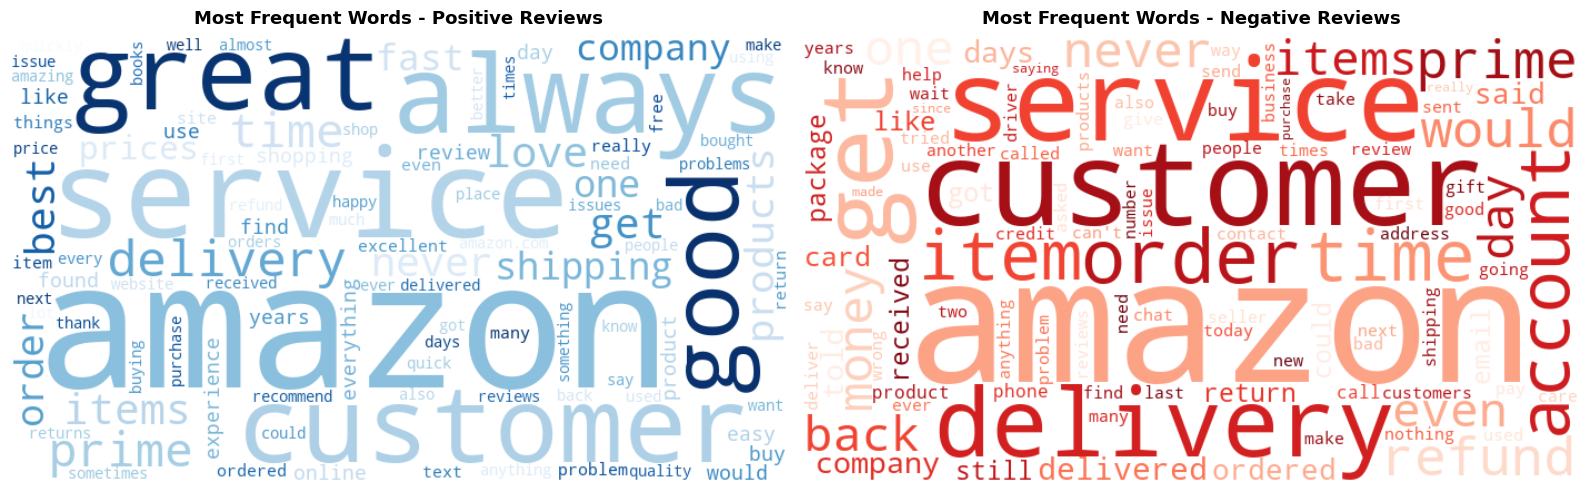

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pos_words = dict(clean_and_count(positive_text, n=100))
wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Blues', max_words=100).generate_from_frequencies(pos_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Most Frequent Words - Positive Reviews', fontsize=13, fontweight='bold', pad=10)
axes[0].axis('off')

neg_words = dict(clean_and_count(negative_text, n=100))
wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate_from_frequencies(neg_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Most Frequent Words - Negative Reviews', fontsize=13, fontweight='bold', pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_sentiment_wordclouds.png'), dpi=150, bbox_inches='tight')
plt.show()

## Word Cloud Finding

The negative word cloud is dominated by account and service contact 
language, "account", "refund", "card", "phone", "called", "credit", 
alongside "service" and "customer" appearing largest. This points to 
specific friction points around payment processing, refunds, and 
customer service contact, rather than general dissatisfaction.

The positive cloud, by contrast, centres on delivery and service 
quality language, "great", "fast", "shipping", "delivery", "love", 
"recommend", reflecting customers praising a smooth, reliable 
experience when things go well.

**Insight:** The prominence of "refund", "card" and "phone" in negative 
reviews specifically points toward payment and refund processing as a 
likely concrete friction point, distinct from delivery itself. This 
gives ShopEase Europe's operations team a more precise target than the 
general "service" theme alone, refund and payment dispute handling 
appears to be a specific, addressable pain point.

## Bigram Analysis - Two-Word Phrases
Single words tell part of the story. Two-word phrases reveal 
the specific combinations driving sentiment, giving product 
and operations teams more precise targets for improvement.

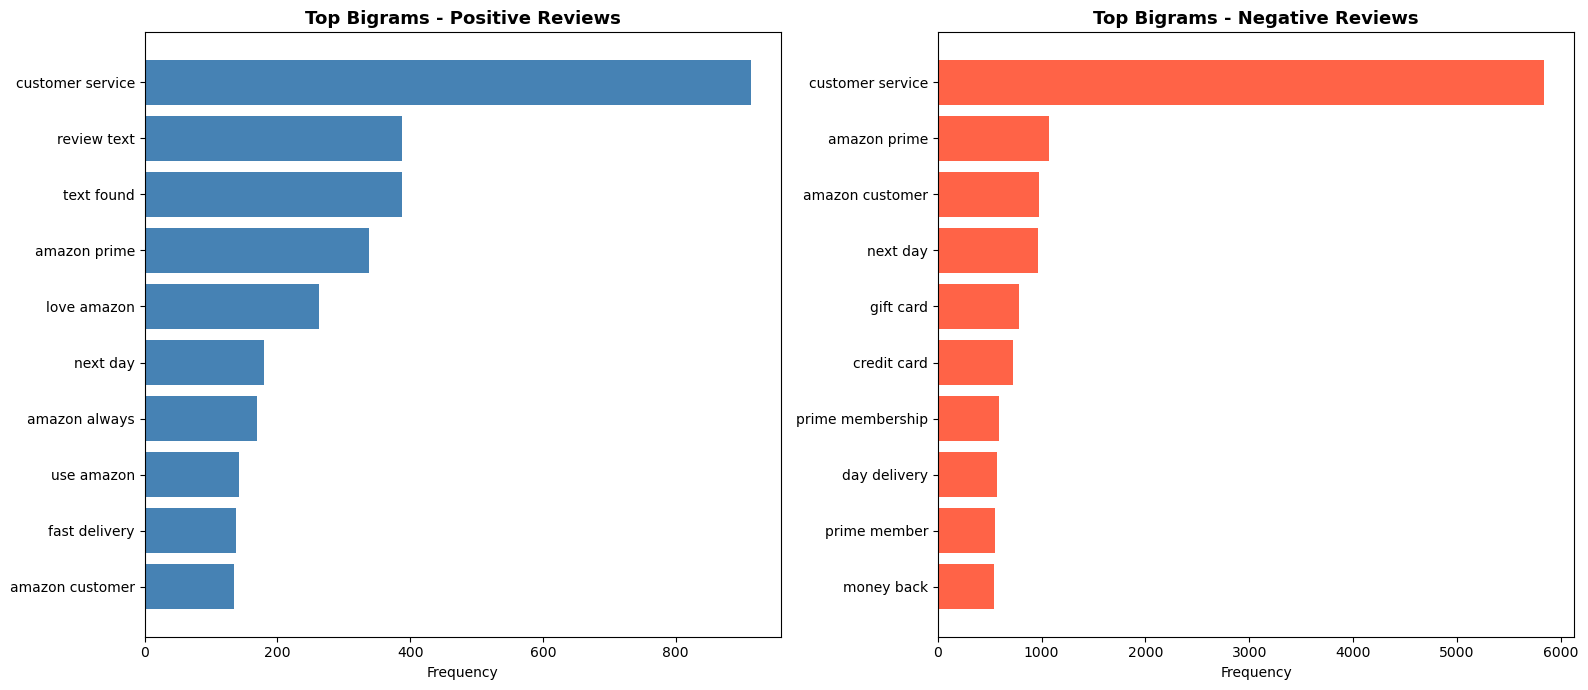

In [7]:
def top_bigrams(text, n=15):
    words = text.lower().split()
    words = [w.strip('.,!?;:\'"()[]') for w in words]
    words = [w for w in words if w not in english_stops and len(w) > 2]
    bigrams = [' '.join(bg) for bg in ngrams(words, 2)]
    return Counter(bigrams).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pos_bigrams = top_bigrams(positive_text, n=10)
pos_labels = [b[0] for b in pos_bigrams]
pos_counts = [b[1] for b in pos_bigrams]
axes[0].barh(pos_labels[::-1], pos_counts[::-1], color='steelblue')
axes[0].set_title('Top Bigrams - Positive Reviews', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].grid(False)

neg_bigrams = top_bigrams(negative_text, n=10)
neg_labels = [b[0] for b in neg_bigrams]
neg_counts = [b[1] for b in neg_bigrams]
axes[1].barh(neg_labels[::-1], neg_counts[::-1], color='tomato')
axes[1].set_title('Top Bigrams - Negative Reviews', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_bigram_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Bigram Finding

Negative reviews are dominated by payment and subscription related 
phrases, "amazon prime", "gift card", "credit card", "prime membership", 
"prime member" and "money back" all rank among the top 10 bigrams. This 
is considerably more specific than the general account and service 
theme identified earlier, pointing directly to Prime subscription 
billing and gift card or credit card payment disputes as concrete, 
recurring complaint topics.

One artifact was identified in the positive bigrams, "review text" and 
"text found" appear to be residual phrasing from the data source rather 
than genuine customer sentiment, and should be disregarded as findings.

**Insight:** The specificity of "gift card", "credit card" and "prime 
membership" issues gives ShopEase Europe's finance and customer service 
teams a precise, actionable target. Rather than a broad service quality 
problem, this suggests billing transparency and payment dispute 
resolution, particularly around Prime subscriptions and gift card 
balances, may be a concentrated source of customer frustration worth 
investigating directly with the relevant systems and policies.

## Payment and Prime Mentions Over Time
Checking whether mentions of payment and subscription related terms 
increased during the 2019 to 2022 sentiment decline identified earlier.

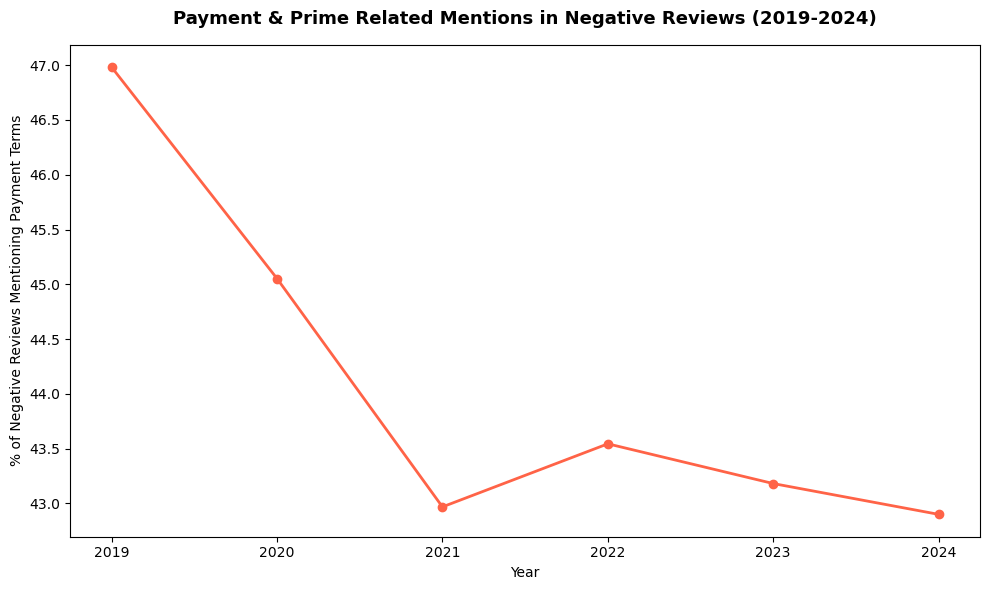

In [8]:
df_recent = df[df['year'] >= 2019].copy()

payment_terms = ['prime', 'gift card', 'credit card', 'refund', 'money back']

def contains_payment_term(text):
    text = str(text).lower()
    return any(term in text for term in payment_terms)

df_recent['mentions_payment_issue'] = df_recent['cleaned_review'].apply(contains_payment_term)

yearly_mentions = df_recent[df_recent['sentiment'] == 'negative'].groupby('year')['mentions_payment_issue'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yearly_mentions.index, yearly_mentions.values, color='tomato', linewidth=2, marker='o')
ax.set_title('Payment & Prime Related Mentions in Negative Reviews (2019-2024)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('% of Negative Reviews Mentioning Payment Terms')
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_payment_mentions_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

## Payment Mentions Trend Finding

Contrary to expectation, payment and Prime related mentions in 
negative reviews were already high in 2019 at 47% and have gradually 
decreased since, to around 43% by 2024. This does not track the sharp 
rise in overall negative sentiment identified earlier, which increased 
substantially over the same period.

**Insight:** This indicates payment and subscription issues represent 
a consistent, longstanding source of complaint rather than the cause 
of the 2019 to 2022 sentiment decline. While still worth addressing as 
an actionable issue given its prevalence, it does not explain why 
overall negative sentiment increased so significantly. The root cause 
of the broader decline likely lies elsewhere, in factors not captured 
by the specific terms tested here, and would benefit from further 
investigation beyond this notebook's scope, potentially through topic 
modelling or a closer reading of high volume complaint periods.

## Category Level Word Trends
Investigating whether specific product categories show a sharper shift 
in complaint themes over time, since payment terms alone do not 
explain the overall sentiment decline.

In [ ]:
df_recent_neg = df[(df['year'] >= 2019) & (df['sentiment'] == 'negative')].copy()

early = df_recent_neg[df_recent_neg['year'].isin([2019, 2020])]
late = df_recent_neg[df_recent_neg['year'].isin([2021, 2022])]

early_text = ' '.join(early['cleaned_review'].astype(str))
late_text = ' '.join(late['cleaned_review'].astype(str))

early_words = dict(clean_and_count(early_text, n=300))
late_words = dict(clean_and_count(late_text, n=300))

# Find words that grew significantly in frequency proportion between periods
early_total = sum(early_words.values())
late_total = sum(late_words.values())

growth = {}
for word in set(early_words) | set(late_words):
    early_rate = early_words.get(word, 0) / early_total * 1000
    late_rate = late_words.get(word, 0) / late_total * 1000
    if early_rate > 0.5:
        growth[word] = late_rate - early_rate

top_growth = sorted(growth.items(), key=lambda x: x[1], reverse=True)[:15]

print("WORDS WITH LARGEST FREQUENCY INCREASE (2019-2020 vs 2021-2022)")
for word, change in top_growth:
    print(f"  {word:<20} {change:+.2f} per 1000 words")

WORDS WITH LARGEST FREQUENCY INCREASE (2019-2020 vs 2021-2022)
  delivery             +2.01 per 1000 words
  company              +1.66 per 1000 words
  driver               +1.44 per 1000 words
  refund               +1.31 per 1000 words
  customer             +1.30 per 1000 words
  delivered            +1.22 per 1000 words
  still                +1.21 per 1000 words
  get                  +0.97 per 1000 words
  return               +0.92 per 1000 words
  drivers              +0.91 per 1000 words
  item                 +0.89 per 1000 words
  left                 +0.87 per 1000 words
  wait                 +0.87 per 1000 words
  give                 +0.87 per 1000 words
  box                  +0.81 per 1000 words


: 

## Category Level Word Trend Finding

Comparing word usage rates in negative reviews between 2019 to 2020 
and 2021 to 2022 reveals delivery operations as the clearest growing 
complaint theme. "Delivery" shows the largest increase at 2.01 
occurrences per 1000 words, followed by "driver" at 1.44, "delivered" 
at 1.22, and "drivers" at 0.91. "Return" and "refund" also increased 
notably, alongside "left", "wait" and "box", suggesting delivery 
failures, late or missing packages, and driver related issues are 
driving an increase in returns and refund requests, rather than 
billing disputes initiating the complaints.

**Insight:** This pinpoints delivery operations, not payment processing, 
as the most likely driver of the 2019 to 2022 sentiment decline. The 
prominence of "driver" and "drivers" specifically suggests last mile 
delivery execution, rather than warehouse or shipping speed alone, may 
be a key factor. This timing also coincides with widely reported global 
delivery and logistics disruption during this period. ShopEase Europe's 
operations team should prioritise auditing last mile delivery partner 
performance and driver conduct as the most promising lead for addressing 
the multi year sentiment decline identified earlier.

## Summary

Word frequency analysis revealed that service and operational language 
dominates both positive and negative reviews, with positive reviews 
pairing these terms with genuine praise and negative reviews pairing 
them with friction indicators like "refund" and "never". Bigram analysis 
initially pointed toward payment and Prime subscription terms as a 
specific complaint theme.

However, testing this hypothesis against the 2019 to 2022 sentiment 
decline revealed that payment and Prime mentions were already high in 
2019 and have since decreased, ruling them out as the cause of the 
decline. A subsequent word level comparison between 2019 to 2020 and 
2021 to 2022 identified delivery operations as the genuine driver, 
"delivery", "driver", "delivered" and "drivers" all showed the largest 
increases in frequency, alongside rising mentions of "return" and 
"refund", suggesting delivery failures are generating downstream 
return and refund activity rather than billing disputes driving 
complaints directly.

### Business Impact
This investigation moved from a broad service quality concern to a 
specific, evidence based conclusion, delivery execution and driver 
conduct, not payment processing, are the most likely root cause behind 
ShopEase Europe's multi year sentiment decline. This timing aligns with 
widely reported global delivery and logistics disruption during 2021 
and 2022. The operations team should prioritise auditing last-mile delivery 
partner performance as the most promising and well evidenced lead, 
with payment and refund process improvements treated as a secondary, 
longstanding issue worth addressing separately rather than the primary 
explanation for the multi-year sentiment decline.